# 02 - Preprocessing Check

**Goal:** trust the per-frame transform pipeline.

Visualize raw vs transformed frames and confirm tensor shape, dtype, and value range. Catches:
- wrong normalization,
- accidental color-channel reordering,
- destructive resizing.

Uses `smth2smth.shared.data.transforms.build_transforms`.

In [23]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent
SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from smth2smth.shared.data import (
    VideoFrameDataset,
    build_transforms,
    collect_video_samples,
)

import matplotlib.pyplot as plt
from PIL import Image
import torch

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
TRAIN_DIR = REPO_ROOT / "data" / "train"
samples = collect_video_samples(TRAIN_DIR)
video_dir, label = samples[0]
frame_path = sorted(video_dir.glob("*.jpg"))[0]
raw = Image.open(frame_path).convert("RGB")

transform_eval = build_transforms(image_size=224, is_training=False)
tensor = transform_eval(raw)
print("tensor shape:", tuple(tensor.shape))
print("tensor dtype:", tensor.dtype)
print("tensor range:", float(tensor.min()), float(tensor.max()))

tensor shape: (3, 224, 224)
tensor dtype: torch.float32
tensor range: -2.1179039478302 2.640000104904175


## Side-by-side: raw vs transformed (un-normalized for display)

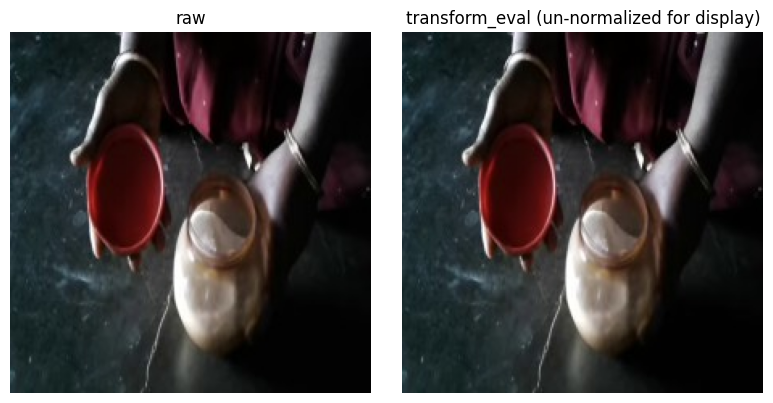

In [25]:
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
display_tensor = (tensor * IMAGENET_STD + IMAGENET_MEAN).clamp(0, 1)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(raw); axes[0].set_title("raw"); axes[0].axis("off")
axes[1].imshow(display_tensor.permute(1, 2, 0).numpy()); axes[1].set_title("transform_eval (un-normalized for display)"); axes[1].axis("off")
plt.tight_layout()

## Full dataset sample shape

In [26]:
ds = VideoFrameDataset(
    root_dir=TRAIN_DIR,
    num_frames=8,
    transform=transform_eval,
)
video_tensor, label_tensor = ds[0]
print("video tensor (T, C, H, W):", tuple(video_tensor.shape))
print("label:", int(label_tensor))

video tensor (T, C, H, W): (8, 3, 224, 224)
label: 0


## Augmentation components preview (`Jitter`, `VideoMix`, `Random Crop`, `TSM`)

Each block shows the full 4-frame trajectory side by side.
Top row is raw frames, bottom row is transformed frames.

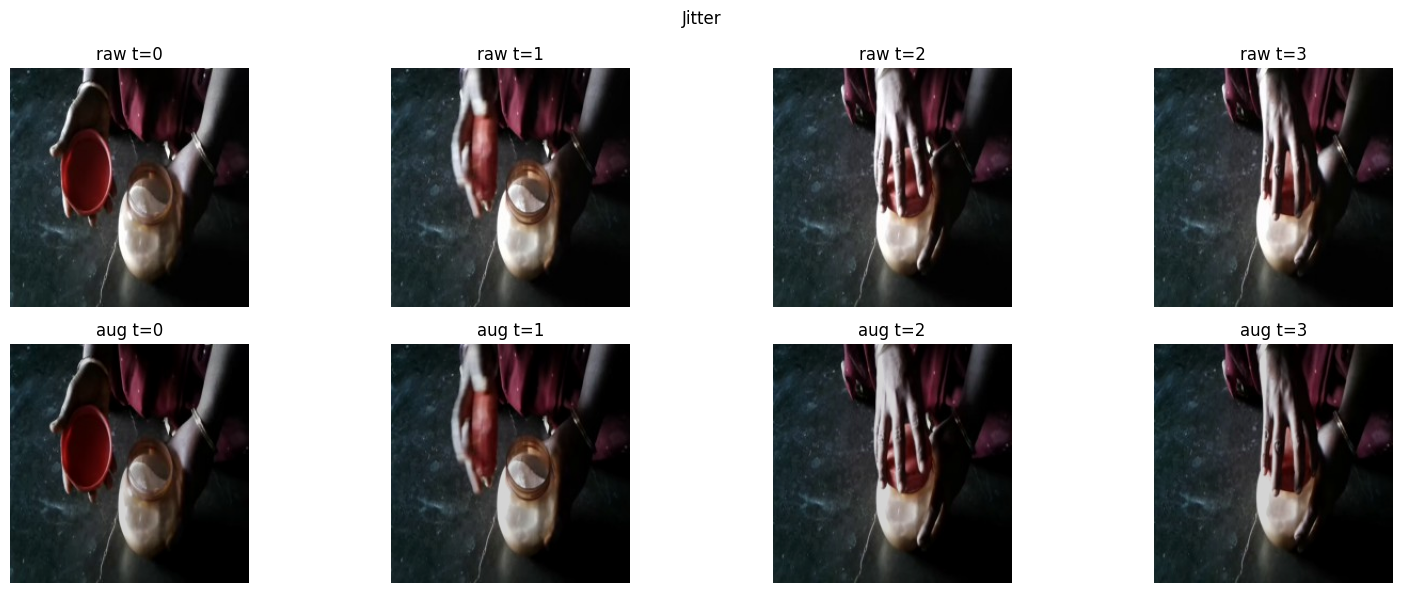

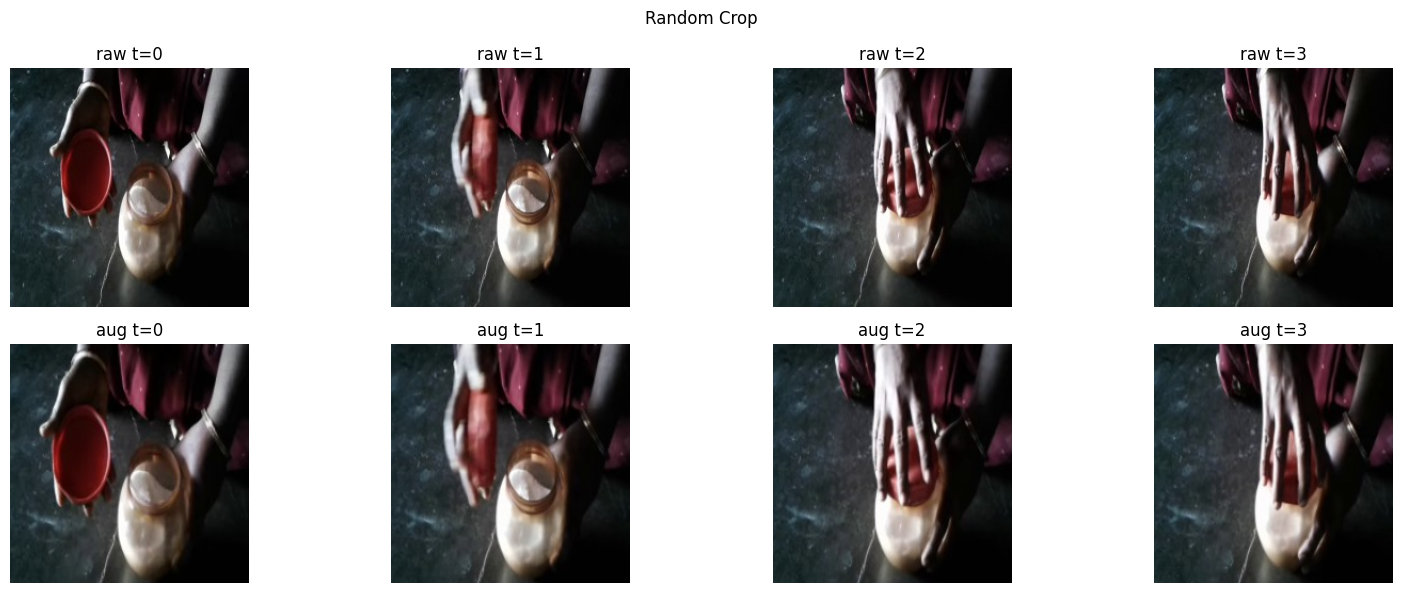

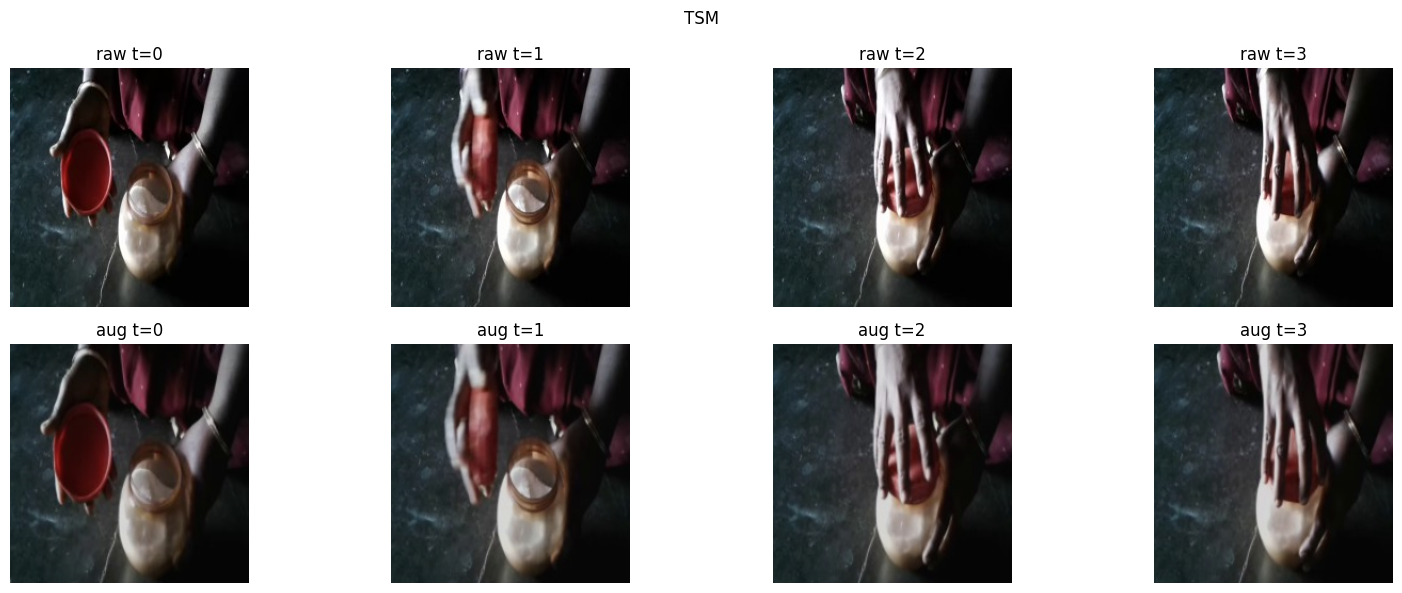

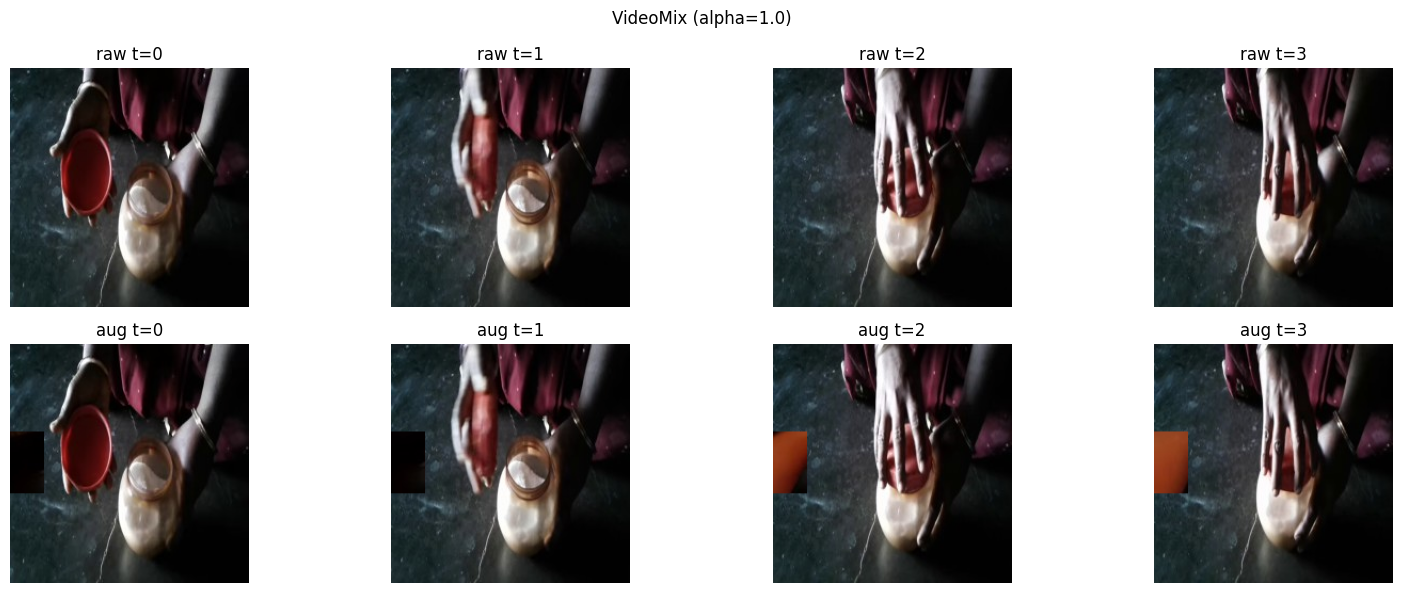

In [27]:
import random


AUG_JITTER = {
    "name": "jitter_only",
    "random_horizontal_flip": False,
    "random_crop": False,
    "crop_padding": 0,
    "color_jitter": True,
    "color_jitter_brightness": 0.25,
    "color_jitter_contrast": 0.25,
    "color_jitter_saturation": 0.25,
    "color_jitter_hue": 0.0,
    "sync_across_frames": True,
}

AUG_RANDOM_CROP = {
    "name": "random_crop_only",
    "random_horizontal_flip": False,
    "random_crop": True,
    "crop_padding": 32,
    "color_jitter": False,
    "sync_across_frames": True,
}

AUG_TSM = {
    "name": "tsm",
    "random_horizontal_flip": False,
    "random_crop": True,
    "crop_padding": 32,
    "color_jitter": True,
    "color_jitter_brightness": 0.2,
    "color_jitter_contrast": 0.2,
    "color_jitter_saturation": 0.2,
    "color_jitter_hue": 0.0,
    "sync_across_frames": True,
}


def _set_seed(seed: int) -> None:
    random.seed(seed)
    torch.manual_seed(seed)


def _to_display_image(tensor: torch.Tensor) -> "np.ndarray":
    disp = (tensor * IMAGENET_STD + IMAGENET_MEAN).clamp(0, 1)
    return disp.permute(1, 2, 0).numpy()


def _apply_videomix(
    clip_a: list[torch.Tensor],
    clip_b: list[torch.Tensor],
    alpha: float = 1.0,
    seed: int = 42,
) -> list[torch.Tensor]:
    _set_seed(seed)
    lam = torch.distributions.Beta(alpha, alpha).sample().item()
    height, width = clip_a[0].shape[-2:]

    cut_ratio = (1.0 - lam) ** 0.5
    cut_w = max(1, int(width * cut_ratio))
    cut_h = max(1, int(height * cut_ratio))

    cx = torch.randint(0, width, (1,)).item()
    cy = torch.randint(0, height, (1,)).item()

    x1 = max(0, cx - cut_w // 2)
    x2 = min(width, cx + cut_w // 2)
    y1 = max(0, cy - cut_h // 2)
    y2 = min(height, cy + cut_h // 2)

    mixed: list[torch.Tensor] = []
    for frame_a, frame_b in zip(clip_a, clip_b):
        frame_out = frame_a.clone()
        frame_out[:, y1:y2, x1:x2] = frame_b[:, y1:y2, x1:x2]
        mixed.append(frame_out)
    return mixed


def _render_trajectory(title: str, raw_frames: list[Image.Image], transformed_frames: list[torch.Tensor]) -> None:
    fig, axes = plt.subplots(2, 4, figsize=(16, 6))
    for idx in range(4):
        axes[0, idx].imshow(raw_frames[idx])
        axes[0, idx].axis("off")
        axes[0, idx].set_title(f"raw t={idx}")

        axes[1, idx].imshow(_to_display_image(transformed_frames[idx]))
        axes[1, idx].axis("off")
        axes[1, idx].set_title(f"aug t={idx}")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def _load_raw_trajectory(start_idx: int = 0, num_frames: int = 4) -> list[Image.Image]:
    from pathlib import Path
    from smth2smth.shared.data.video_dataset import (
        _list_frame_paths,
        collect_video_samples,
        pick_frame_indices,
    )

    samples = collect_video_samples(Path(TRAIN_DIR))
    video_dir, _label = samples[start_idx]
    frame_paths = _list_frame_paths(video_dir)
    indices = pick_frame_indices(len(frame_paths), num_frames)

    frames: list[Image.Image] = []
    for frame_idx in indices:
        with Image.open(frame_paths[frame_idx]) as image:
            frames.append(image.convert("RGB"))
    return frames


def _apply_component_aug(raw_frames: list[Image.Image], aug_cfg: dict, seed: int = 42) -> list[torch.Tensor]:
    _set_seed(seed)
    transform = build_transforms(
        image_size=224,
        is_training=True,
        use_imagenet_norm=True,
        augment=aug_cfg,
    )
    out = transform(raw_frames)
    return list(out)


raw_clip_a = _load_raw_trajectory(start_idx=0, num_frames=4)
raw_clip_b = _load_raw_trajectory(start_idx=1, num_frames=4)

jitter_clip = _apply_component_aug(raw_clip_a, AUG_JITTER, seed=11)
_render_trajectory("Jitter", raw_clip_a, jitter_clip)

crop_clip = _apply_component_aug(raw_clip_a, AUG_RANDOM_CROP, seed=22)
_render_trajectory("Random Crop", raw_clip_a, crop_clip)

tsm_clip = _apply_component_aug(raw_clip_a, AUG_TSM, seed=33)
_render_trajectory("TSM", raw_clip_a, tsm_clip)

base_eval_transform = build_transforms(
    image_size=224,
    is_training=False,
    use_imagenet_norm=True,
)
clip_a_eval = [base_eval_transform(img) for img in raw_clip_a]
clip_b_eval = [base_eval_transform(img) for img in raw_clip_b]
videomix_clip = _apply_videomix(clip_a_eval, clip_b_eval, alpha=1.0, seed=44)
_render_trajectory("VideoMix (alpha=1.0)", raw_clip_a, videomix_clip)

In [28]:
# Temporal consistency check: with sync_across_frames=True, two identical frames
# should receive the same random crop/jitter parameters.

sync_transform = build_transforms(
    image_size=224,
    is_training=True,
    use_imagenet_norm=True,
    augment=AUG_TSM,
)

frame_a = raw.copy()
frame_b = raw.copy()
out_seq = sync_transform([frame_a, frame_b])

max_abs_diff = (out_seq[0] - out_seq[1]).abs().max().item()
print("max abs diff between two identical frames after synced augmentation:", max_abs_diff)
print("(Expected: 0.0 or tiny floating-point noise)")

max abs diff between two identical frames after synced augmentation: 0.0
(Expected: 0.0 or tiny floating-point noise)
